In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
 
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, roc_auc_score,
                                        RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.preprocessing      import StandardScaler
from imblearn.over_sampling     import SMOTE
import xgboost as xgb
 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load Data

In [3]:
df = pd.read_csv('../data/earthquake_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (782, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


## Preprocessing

In [4]:
# Keep only the columns we'll use — drop high-null and non-informative cols.
# We keep magType because it encodes seismic measurement method (informative).
# We drop: title (free text), location/continent/country (high null + lat/lng
# already capture geography), alert (47% null — we'd lose half the dataset),
# net (95% US — near-zero variance).
 
KEEP_COLS = ['magnitude', 'cdi', 'mmi', 'tsunami', 'sig',
             'nst', 'dmin', 'gap', 'magType', 'depth',
             'latitude', 'longitude', 'date_time']
 
df = df[KEEP_COLS].copy()
 
# Parse date and extract cyclical time features
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)
df['month_sin'] = np.sin(2 * np.pi * df['date_time'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date_time'].dt.month / 12)
df['year']      = df['date_time'].dt.year
df.drop('date_time', axis=1, inplace=True)
 
# Encode magType — use pd.get_dummies (one-hot) to avoid ordinal assumption
df = pd.get_dummies(df, columns=['magType'], drop_first=True)
 
print("Null counts after cleaning:")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")
df.head()

Null counts after cleaning:
magnitude      0
cdi            0
mmi            0
tsunami        0
sig            0
nst            0
dmin           0
gap            0
depth          0
latitude       0
longitude      0
month_sin      0
month_cos      0
year           0
magType_mb     0
magType_md     0
magType_ml     0
magType_ms     0
magType_mw     0
magType_mwb    0
magType_mwc    0
magType_mww    0
dtype: int64

Final shape: (782, 22)


,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude,month_sin,month_cos,year,magType_mb,magType_md,magType_ml,magType_ms,magType_mw,magType_mwb,magType_mwc,magType_mww
0,7.0,8,7,1,768,117,0.509,17.0,14.000,-9.7963,159.596,-0.5,0.866025,2022,False,False,False,False,False,False,False,True
1,6.9,4,4,0,735,99,2.229,34.0,25.000,-4.9559,100.738,-0.5,0.866025,2022,False,False,False,False,False,False,False,True
2,7.0,3,3,1,755,147,3.125,18.0,579.000,-20.0508,-178.346,-0.5,0.866025,2022,False,False,False,False,False,False,False,True
3,7.3,5,5,1,833,149,1.865,21.0,37.000,-19.2918,-172.129,-0.5,0.866025,2022,False,False,False,False,False,False,False,True
4,6.6,0,2,1,670,131,4.998,27.0,624.464,-25.5948,178.278,-0.5,0.866025,2022,False,False,False,False,False,False,False,True


## EDA — Target Distribution

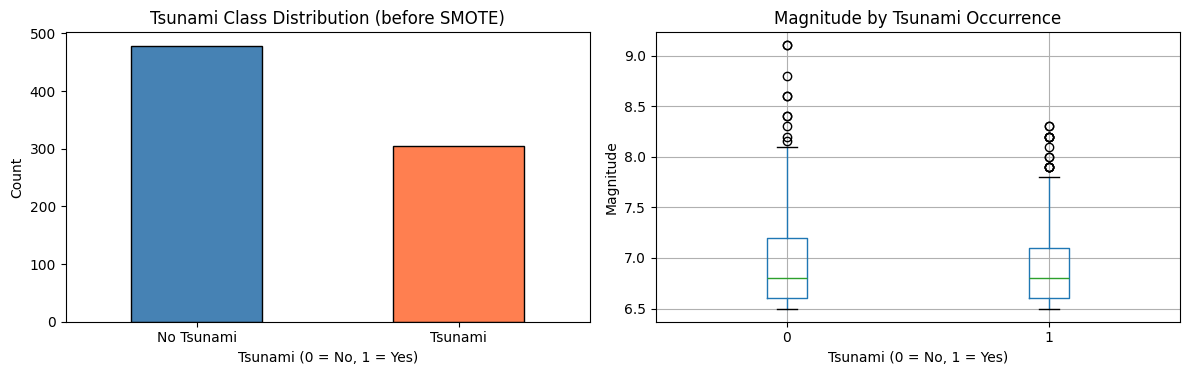

Class balance:
tsunami
0    478
1    304
Name: count, dtype: int64
Tsunami rate: 38.9%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Class balance
df['tsunami'].value_counts().plot(kind='bar', ax=axes[0],
                                   color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Tsunami Class Distribution (before SMOTE)')
axes[0].set_xlabel('Tsunami (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Tsunami', 'Tsunami'], rotation=0)
 
# Magnitude vs tsunami
df.boxplot(column='magnitude', by='tsunami', ax=axes[1])
axes[1].set_title('Magnitude by Tsunami Occurrence')
axes[1].set_xlabel('Tsunami (0 = No, 1 = Yes)')
axes[1].set_ylabel('Magnitude')
plt.suptitle('')
plt.tight_layout()
plt.show()
 
print(f"Class balance:\n{df['tsunami'].value_counts()}")
print(f"Tsunami rate: {df['tsunami'].mean():.1%}")

## Correlation Heatmap

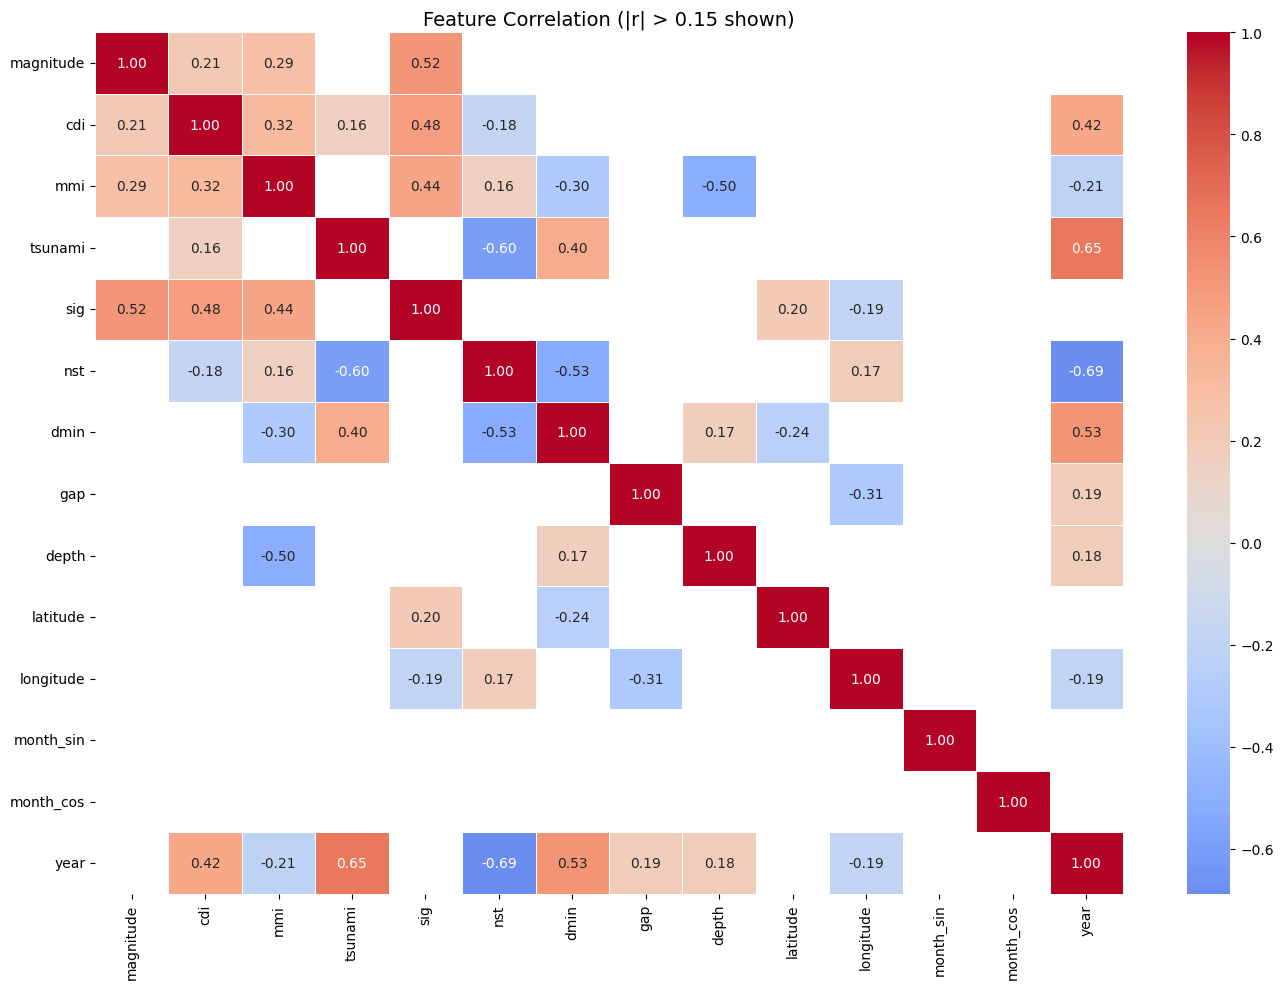

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
 
plt.figure(figsize=(14, 10))
mask = np.abs(corr) < 0.15   # hide near-zero correlations for readability
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation (|r| > 0.15 shown)', fontsize=14)
plt.tight_layout()
plt.show()

## Train/Test Split — BEFORE scaling

In [7]:
FEATURES = [c for c in df.columns if c != 'tsunami']
TARGET   = 'tsunami'
 
X = df[FEATURES]
y = df[TARGET]
 
# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
# Scale AFTER splitting — fit only on train, transform both
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)          # ← transform only, never fit
 
X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES)
 
print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

Train: (625, 21) | Test: (157, 21)
Train class balance:
tsunami
0    382
1    243
Name: count, dtype: int64


## Handle Class Imbalance with SMOTE

In [8]:
# SMOTE only on training data — never touch the test set
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)
 
print(f"After SMOTE — Train shape: {X_train_res.shape}")
print(f"Class balance after SMOTE:\n{pd.Series(y_train_res).value_counts()}")

After SMOTE — Train shape: (764, 21)
Class balance after SMOTE:
tsunami
0    382
1    382
Name: count, dtype: int64


## Train Multiple Models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  random_state=42, n_jobs=-1),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, max_depth=6,
                                             learning_rate=0.1, use_label_encoder=False,
                                             eval_metric='logloss', random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                      learning_rate=0.1, random_state=42),
}
 
results = {}
 
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_sc)
    y_prob = (model.predict_proba(X_test_sc)[:, 1]
              if hasattr(model, 'predict_proba') else None)
 
    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    cv_acc = cross_val_score(model, X_train_res, y_train_res,
                             cv=StratifiedKFold(5), scoring='accuracy').mean()
 
    results[name] = {'model': model, 'acc': acc, 'roc_auc': roc, 'cv_acc': cv_acc,
                     'y_pred': y_pred, 'y_prob': y_prob}
 
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  ROC-AUC       : {roc:.4f}" if roc else "  ROC-AUC: N/A")
    print(f"  CV Accuracy   : {cv_acc:.4f}  (5-fold, on train set)")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Tsunami','Tsunami'])}")
 


  Logistic Regression
  Test Accuracy : 0.8726
  ROC-AUC       : 0.9406
  CV Accuracy   : 0.8718  (5-fold, on train set)

              precision    recall  f1-score   support

  No Tsunami       0.95      0.83      0.89        96
     Tsunami       0.78      0.93      0.85        61

    accuracy                           0.87       157
   macro avg       0.87      0.88      0.87       157
weighted avg       0.89      0.87      0.87       157


  Decision Tree
  Test Accuracy : 0.8981
  ROC-AUC       : 0.9057
  CV Accuracy   : 0.9111  (5-fold, on train set)

              precision    recall  f1-score   support

  No Tsunami       0.92      0.92      0.92        96
     Tsunami       0.87      0.87      0.87        61

    accuracy                           0.90       157
   macro avg       0.89      0.89      0.89       157
weighted avg       0.90      0.90      0.90       157


  Random Forest
  Test Accuracy : 0.9490
  ROC-AUC       : 0.9667
  CV Accuracy   : 0.9045  (5-fold, on t

## Visual Comparison

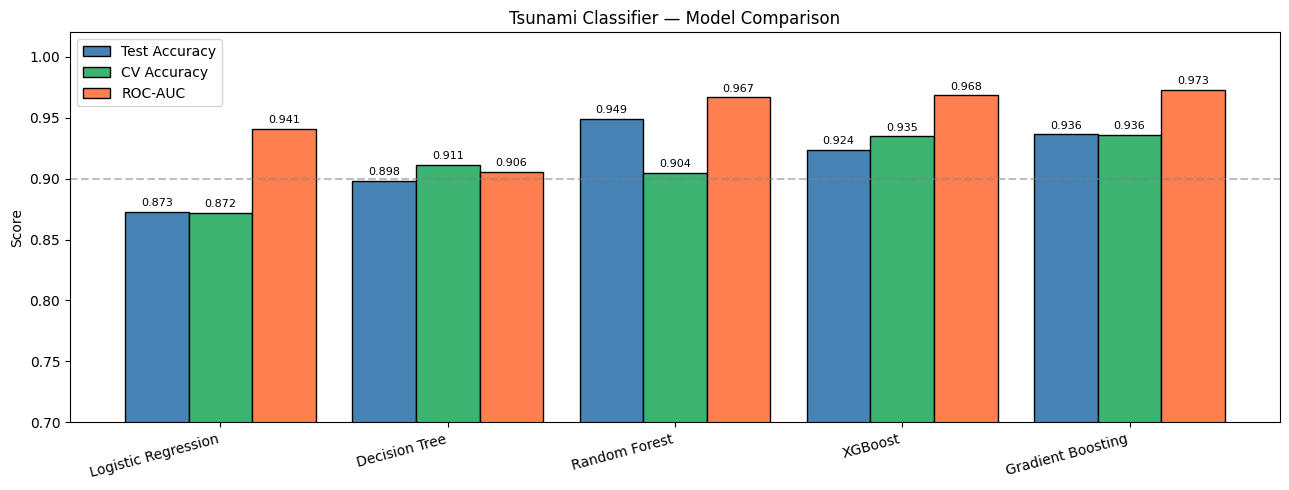

In [10]:
names   = list(results.keys())
accs    = [results[n]['acc']     for n in names]
rocs    = [results[n]['roc_auc'] for n in names]
cv_accs = [results[n]['cv_acc']  for n in names]
 
x = np.arange(len(names))
width = 0.28
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, accs,    width, label='Test Accuracy',   color='steelblue',  edgecolor='black')
ax.bar(x,         cv_accs, width, label='CV Accuracy',     color='mediumseagreen', edgecolor='black')
ax.bar(x + width, rocs,    width, label='ROC-AUC',         color='coral',      edgecolor='black')
 
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_title('Tsunami Classifier — Model Comparison')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
 
for i, (a, c, r) in enumerate(zip(accs, cv_accs, rocs)):
    ax.text(i - width, a + 0.003, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i,         c + 0.003, f'{c:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width, r + 0.003, f'{r:.3f}', ha='center', va='bottom', fontsize=8)
 
plt.tight_layout()
plt.show()

## Best Model — Confusion Matrix & ROC Curve

Best model: Gradient Boosting  (ROC-AUC = 0.9727)


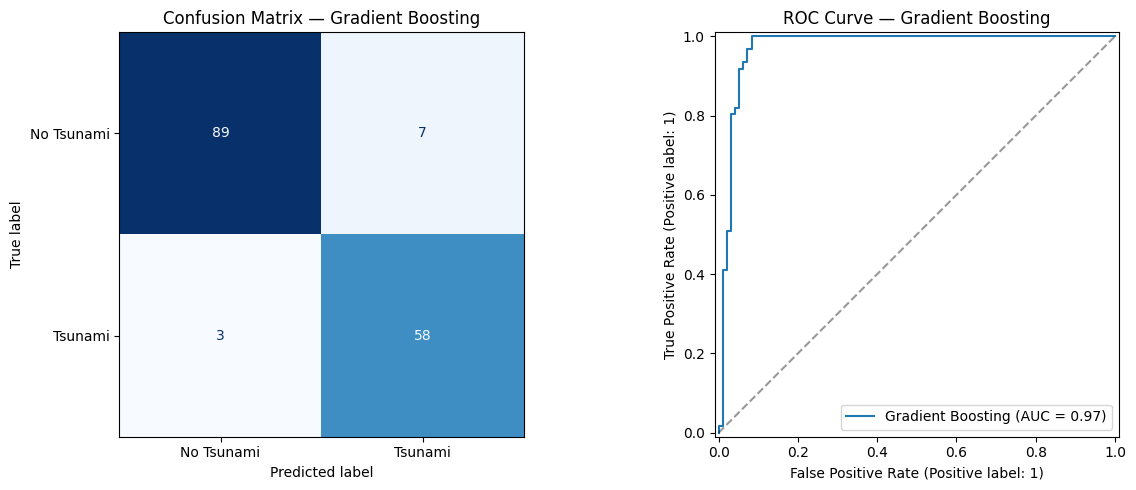

In [11]:
# Pick best by ROC-AUC
best_name  = max(results, key=lambda n: results[n]['roc_auc'])
best       = results[best_name]
print(f"Best model: {best_name}  (ROC-AUC = {best['roc_auc']:.4f})")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best['y_pred']),
    display_labels=['No Tsunami', 'Tsunami']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}')
 
# ROC curve
RocCurveDisplay.from_predictions(
    y_test, best['y_prob'], name=best_name, ax=axes[1]
)
axes[1].set_title(f'ROC Curve — {best_name}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
 
plt.tight_layout()
plt.show()

## Feature Importance (for tree-based best model)

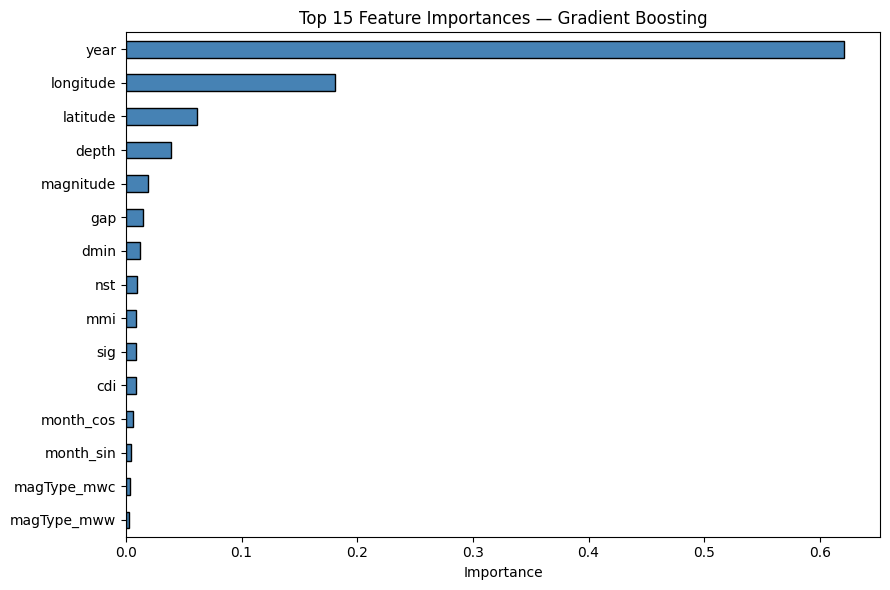

In [12]:
model_obj = best['model']
 
if hasattr(model_obj, 'feature_importances_'):
    imp = pd.Series(model_obj.feature_importances_, index=FEATURES).sort_values(ascending=True)
    top = imp.tail(15)
 
    plt.figure(figsize=(9, 6))
    top.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(model_obj, 'coef_'):
    coefs = pd.Series(np.abs(model_obj.coef_[0]), index=FEATURES).sort_values(ascending=True)
    top = coefs.tail(15)
    plt.figure(figsize=(9, 6))
    top.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Top 15 Feature Coefficients (|value|) — {best_name}')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## Validation Curve

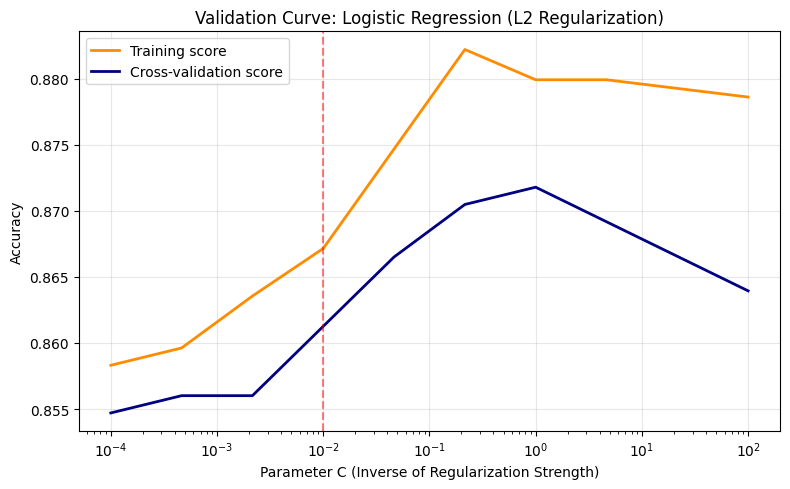

In [13]:
from sklearn.model_selection import validation_curve

# Step 4: Analyzing Bias-Variance Tradeoff via Regularization (L2 Penalty)
param_range = np.logspace(-4, 2, 10) # Testing C from 0.0001 to 100

train_scores, test_scores = validation_curve(
    LogisticRegression(penalty='l2', max_iter=1000, random_state=42),
    X_train_res, y_train_res, 
    param_name="C", 
    param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range, train_mean, label="Training score", color="darkorange", lw=2)
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.title("Validation Curve: Logistic Regression (L2 Regularization)")
plt.xlabel("Parameter C (Inverse of Regularization Strength)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.axvline(x=0.01, color='red', linestyle='--', alpha=0.5, label='Optimal Regularization')
plt.tight_layout()
plt.show()

## Threshold Tuning

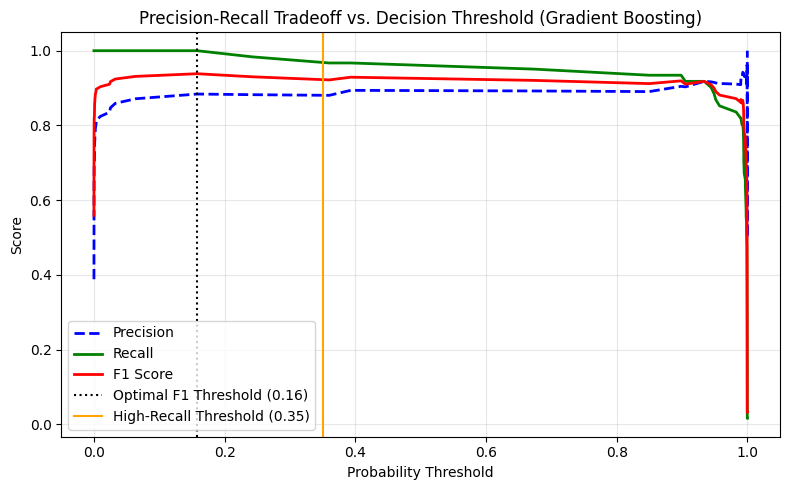

Default Threshold (0.50) Recall : 0.9508
Safe Threshold (0.35) Recall    : 0.9672


In [15]:
from sklearn.metrics import precision_recall_curve, f1_score

# Step 5: Threshold Selection Impact
best_model = best['model']
y_prob_best = best['y_prob']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

# Calculate F1 scores across all thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", lw=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", lw=2)
plt.plot(thresholds, f1_scores, "r-", label="F1 Score", lw=2)
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal F1 Threshold ({optimal_threshold:.2f})')

# Disaster Management adjustment: Shift threshold left to prioritize Recall
safe_threshold = 0.35 
plt.axvline(x=safe_threshold, color='orange', linestyle='-', label=f'High-Recall Threshold ({safe_threshold:.2f})')

plt.title(f"Precision-Recall Tradeoff vs. Decision Threshold ({best_name})")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show impact of changing threshold
y_pred_default = (y_prob_best >= 0.5).astype(int)
y_pred_safe = (y_prob_best >= safe_threshold).astype(int)

print(f"Default Threshold (0.50) Recall : {classification_report(y_test, y_pred_default, output_dict=True)['1']['recall']:.4f}")
print(f"Safe Threshold ({safe_threshold:.2f}) Recall    : {classification_report(y_test, y_pred_safe, output_dict=True)['1']['recall']:.4f}")

## Save Best Model + Scaler

In [14]:
os.makedirs('../models', exist_ok=True)
 
joblib.dump(best['model'], '../models/tsunami_model.pkl')
joblib.dump(scaler,        '../models/tsunami_scaler.pkl')
joblib.dump(FEATURES,      '../models/tsunami_features.pkl')
 
print(f"Saved tsunami_model.pkl  ({best_name})")
print(f"Saved tsunami_scaler.pkl")
print(f"Saved tsunami_features.pkl")
print(f"\nFinal model performance:")
print(f"  Test Accuracy : {best['acc']:.4f}")
print(f"  ROC-AUC       : {best['roc_auc']:.4f}")
print(f"  CV Accuracy   : {best['cv_acc']:.4f}")

Saved tsunami_model.pkl  (Gradient Boosting)
Saved tsunami_scaler.pkl
Saved tsunami_features.pkl

Final model performance:
  Test Accuracy : 0.9363
  ROC-AUC       : 0.9727
  CV Accuracy   : 0.9359
